<a href="https://colab.research.google.com/github/Jeelchotaliya7/thrinax_internship_task/blob/main/thrinax-task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The objective is to segment customers based on demographic and purchasing behavior using clustering techniques and identify meaningful customer groups for business decision-making.

In [23]:
pip install pandas numpy matplotlib seaborn scikit-learn


In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [25]:
df = pd.read_csv("customers.csv")

print(df.head())
print(df.info())
print(df.describe())

   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)
0        1000      M  39.0                59.9                    58.0
1        1001      M  34.0                48.4                    37.0
2        1002      F  40.0                70.5                    26.0
3        1003      F  47.0                81.1                    30.0
4        1004      F  33.0                42.1                    58.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB
None
        CustomerID         Age

In [26]:
# Check missing values

print(df.isnull().sum())

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64


In [27]:
# Remove missing values

df = df.dropna()

In [28]:
# Remove duplicates

df = df.drop_duplicates()

Age Distribution

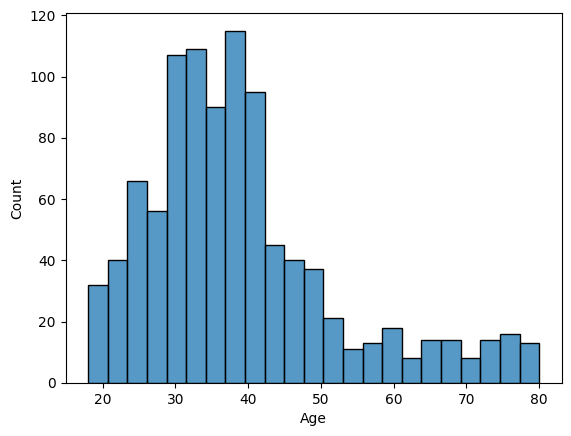

In [29]:
sns.histplot(df['Age'])
plt.show()

Income distribution

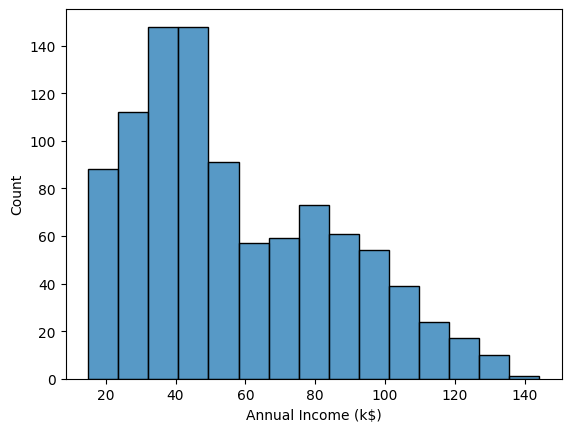

In [30]:
sns.histplot(df['Annual Income (k$)'])
plt.show()

Correlation

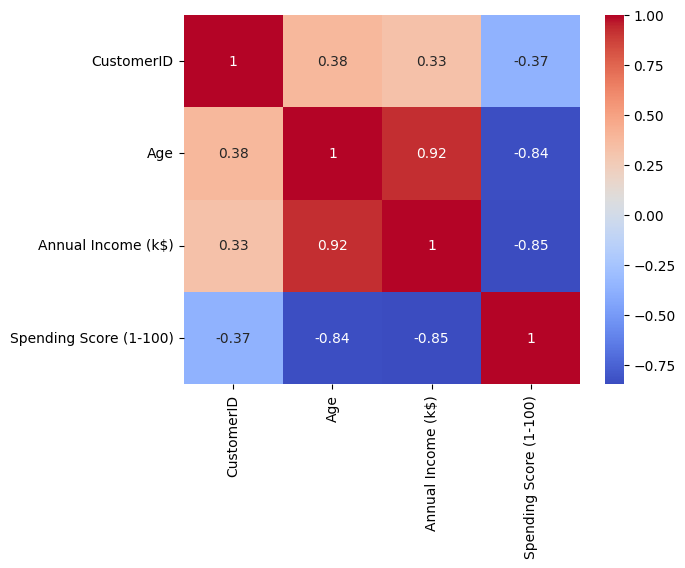

In [31]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()

Features for Clustering

In [32]:
X = df[['Age',
        'Annual Income (k$)',
        'Spending Score (1-100)',
        ]]

Scale Data

In [33]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Find Optimal Number of Clusters

In [34]:
wcss=[]

for i in range(1,11):

    kmeans=KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

Plot

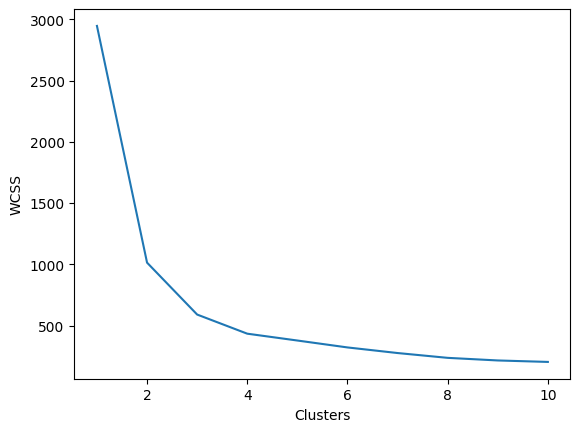

In [35]:
plt.plot(range(1,11),wcss)

plt.xlabel("Clusters")
plt.ylabel("WCSS")

plt.show()

Apply K-Means Clustering

In [36]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['Cluster']=kmeans.fit_predict(X_scaled)

Visualize Customer Segments

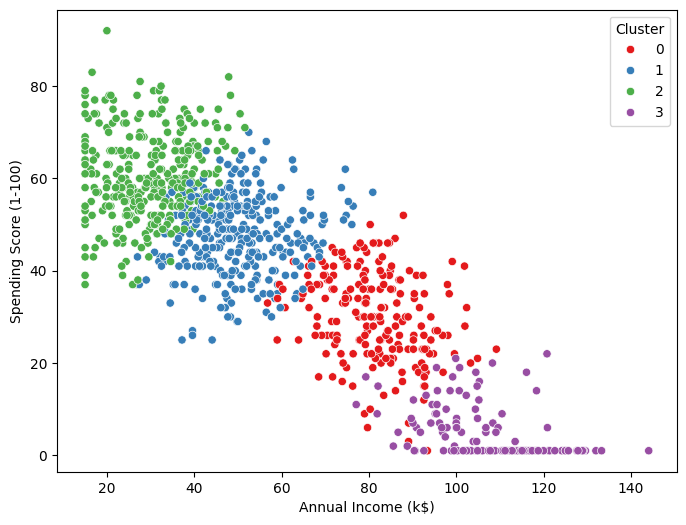

In [37]:
plt.figure(figsize=(8,6))

sns.scatterplot(
x='Annual Income (k$)',
y='Spending Score (1-100)',
hue='Cluster',
data=df,
palette='Set1'
)

plt.show()

Analyze Cluster Characteristics

In [41]:
cluster_summary=df.groupby(
'Cluster'
).mean(numeric_only=True).round(0).astype(int)

print(cluster_summary)

         CustomerID  Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                             
0              1483   45                  81                      30
1              1418   36                  49                      48
2              1461   27                  29                      60
3              1837   67                 108                       5


Generate Business Insights

eg -

| Segment         | Recommendation         |
| --------------- | ---------------------- |
| High spenders   | VIP offers             |
| Low spenders    | Discount campaigns     |
| Frequent buyers | Loyalty programs       |
| Young customers | Social media marketing |


In [42]:
df.to_csv(
'customer_segmented.csv',
index=False
)

In [45]:
from google.colab import files
files.download("customer_segmented.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
from google.colab import files
uploaded = files.upload()

print("Power BI file uploaded successfully")

Saving thrinax_task_2.pbix to thrinax_task_2 (2).pbix
Power BI file uploaded successfully


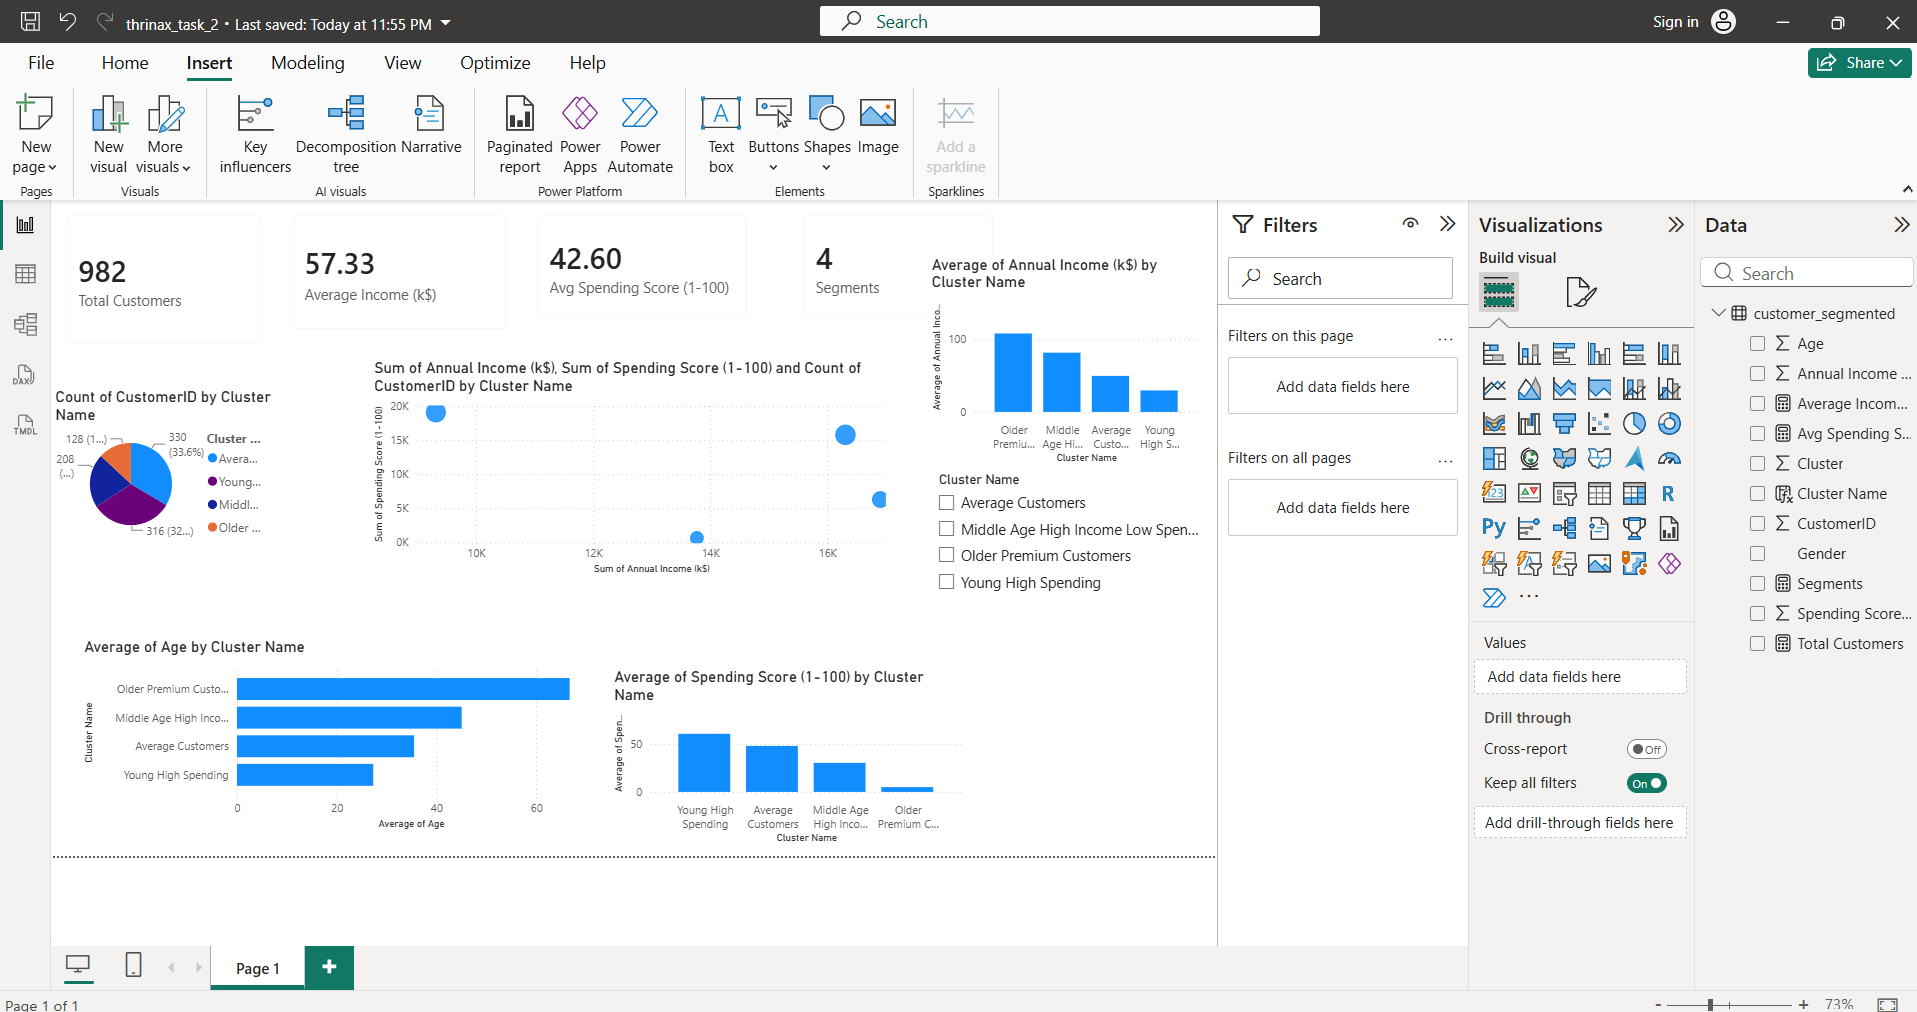

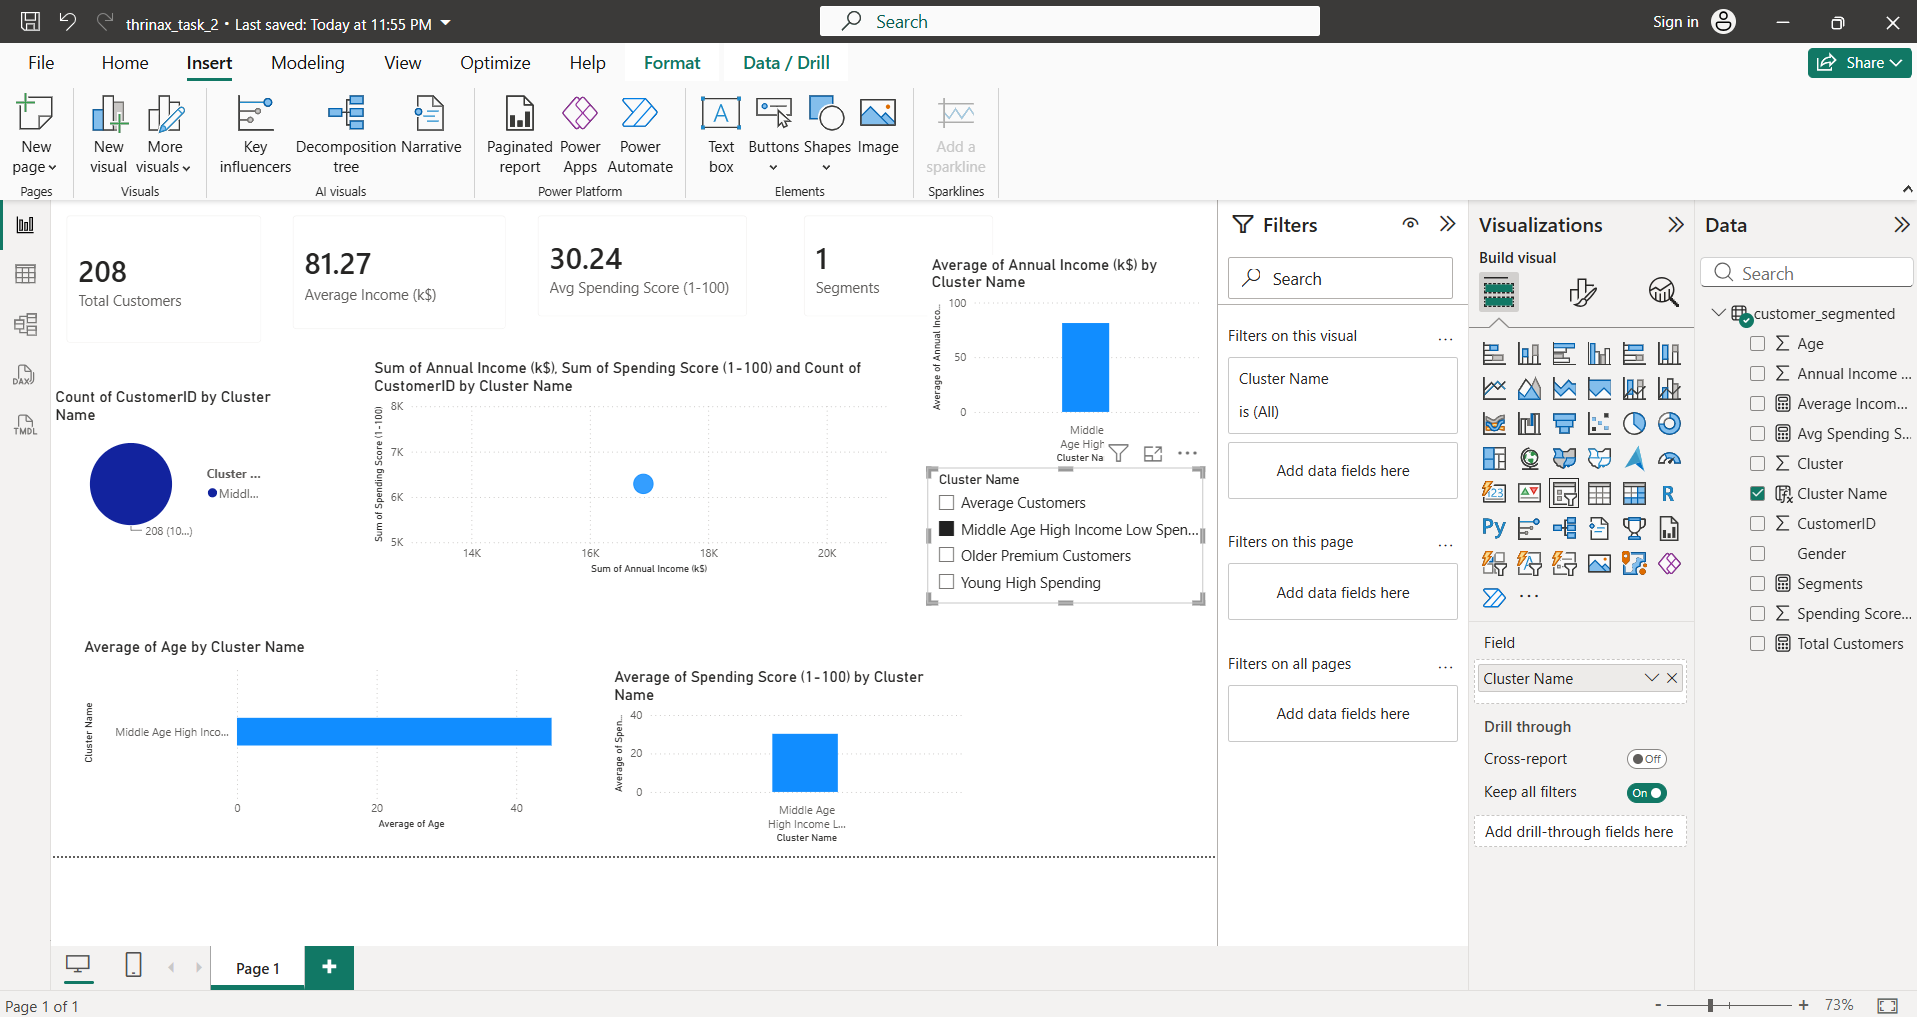